In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
import networkx as nx
print(f"Версия NetworkX: {nx.__version__}")

Версия NetworkX: 3.2.1


In [3]:
# Создаем первый граф (K4)
G1 = nx.Graph()
G1.add_edges_from([(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 1)])

# Создаем второй граф (K5)
G2 = nx.Graph()
G2.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5), (5, 1), 
                   (1, 3), (1, 4), (2, 5), (2, 4), (3, 5)])

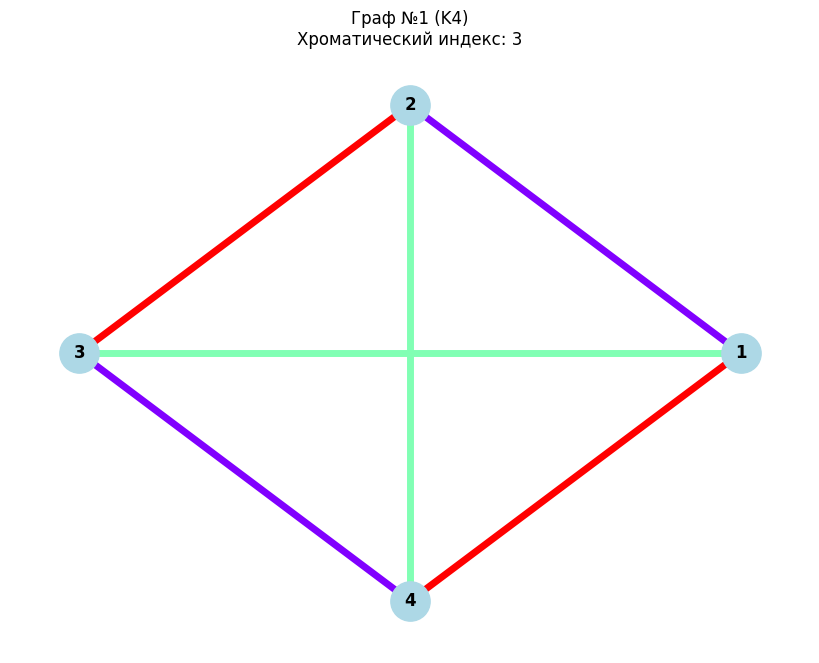

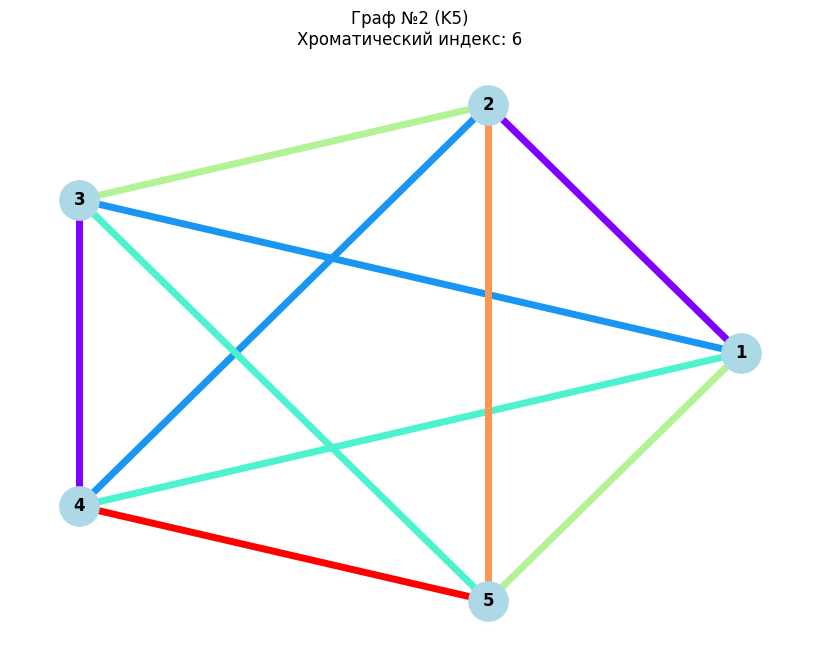

In [4]:
def color_edges(G, title):
    try:
        coloring = nx.coloring.greedy_edge_coloring(G, strategy="largest_first")
    except AttributeError:
        line_graph = nx.line_graph(G)
        node_coloring = nx.coloring.greedy_color(line_graph, strategy="largest_first")
        # Переносим раскраску с вершин линейного графа на ребра исходного
        coloring = node_coloring

    # Подготавливаем список цветов
    edge_colors_list = []
    for u, v in G.edges():
        color = coloring.get((u, v)) if (u, v) in coloring else coloring.get((v, u))
        edge_colors_list.append(color)
    
    chromatic_index = len(set(edge_colors_list))
    
    # Визуализация
    plt.figure(figsize=(8, 6))
    pos = nx.circular_layout(G)
    
    nx.draw(G, pos, 
            with_labels=True, 
            node_color='lightblue', 
            edge_color=edge_colors_list, 
            width=5, 
            edge_cmap=plt.cm.rainbow,
            node_size=800, 
            font_weight='bold')
    
    plt.title(f"{title}\nХроматический индекс: {chromatic_index}")
    plt.show()
    return chromatic_index

# Инициализация графов
G1 = nx.Graph()
G1.add_edges_from([(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 1)])

G2 = nx.Graph()
G2.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5), (5, 1), 
                   (1, 3), (1, 4), (2, 5), (2, 4), (3, 5)])

index1 = color_edges(G1, "Граф №1 (K4)")
index2 = color_edges(G2, "Граф №2 (K5)")

Всего найдено путей от E до F: 12
Из них с разноцветными ребрами: 2
------------------------------
КРАТЧАЙШИЙ РАЗНОЦВЕТНЫЙ ПУТЬ: E -> A -> G -> F
Общий вес: 13


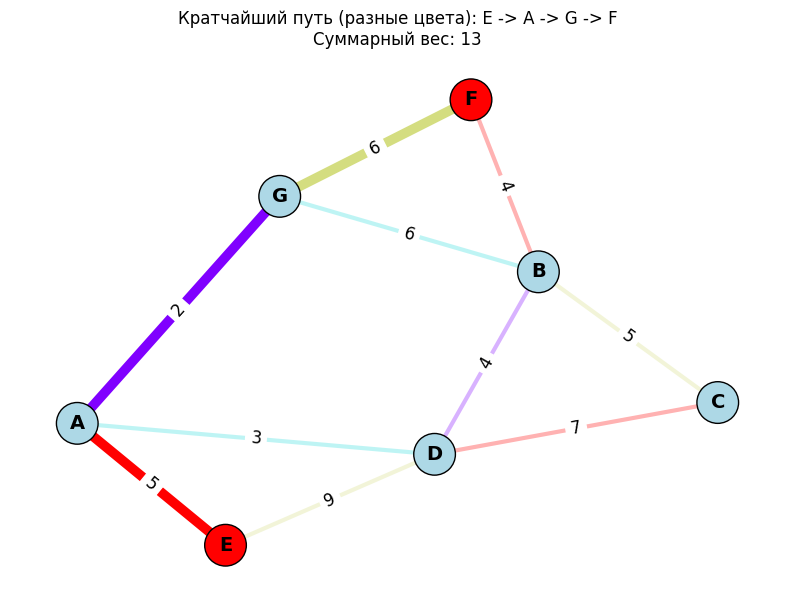

In [10]:
# Инициализируем граф
G = nx.Graph()

# Добавляем ребра с весами
edges = [
    ('B', 'C', 5), ('C', 'D', 7), ('B', 'D', 4),
    ('B', 'F', 4), ('B', 'G', 6), ('F', 'G', 6),
    ('D', 'A', 3), ('G', 'A', 2), ('D', 'E', 9), ('A', 'E', 5)
]
G.add_weighted_edges_from(edges)

# 1. Программная раскраска ребер (наш проверенный метод)
try:
    coloring = nx.coloring.greedy_edge_coloring(G, strategy="largest_first")
except AttributeError:
    line_graph = nx.line_graph(G)
    coloring = nx.coloring.greedy_color(line_graph, strategy="largest_first")

# Сохраняем цвета ребер в удобный словарь для обоих направлений
edge_colors_dict = {}
for u, v in G.edges():
    c = coloring.get((u, v)) if (u, v) in coloring else coloring.get((v, u))
    edge_colors_dict[(u, v)] = c
    edge_colors_dict[(v, u)] = c

# 2. Поиск всех путей между красными вершинами 'E' и 'F'
paths = list(nx.all_simple_paths(G, source='E', target='F'))
valid_paths = []

for path in paths:
    # Разбиваем путь на список ребер: например, ['E', 'A', 'G'] -> [('E', 'A'), ('A', 'G')]
    path_edges = list(zip(path[:-1], path[1:]))
    
    # Получаем цвета для ребер этого пути
    path_colors = [edge_colors_dict[e] for e in path_edges]
    
    # Главное условие: количество цветов должно быть равно количеству УНИКАЛЬНЫХ цветов (нет дублей)
    if len(path_colors) == len(set(path_colors)):
        # Если условие выполнено, считаем общий вес пути
        weight = sum(G[u][v]['weight'] for u, v in path_edges)
        valid_paths.append({
            'path': path,
            'weight': weight,
            'colors': path_colors,
            'edges': path_edges
        })

# 3. Визуализация и вывод результатов
plt.figure(figsize=(10, 7))
# Используем spring_layout для наглядного распределения вершин
pos = nx.spring_layout(G, seed=42) 

# Рисуем базовый граф (делаем ребра полупрозрачными, чтобы потом выделить путь)
all_edge_colors = [edge_colors_dict[(u, v)] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, alpha=0.3, width=3, edge_color=all_edge_colors, edge_cmap=plt.cm.rainbow)

# Рисуем вершины (E и F делаем красными, остальные голубыми)
node_colors = ['red' if node in ['E', 'F'] else 'lightblue' for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# Ищем и выделяем кратчайший валидный путь
if valid_paths:
    # Сортируем пути по весу
    valid_paths.sort(key=lambda x: x['weight'])
    best_path = valid_paths[0]
    
    print(f"Всего найдено путей от E до F: {len(paths)}")
    print(f"Из них с разноцветными ребрами: {len(valid_paths)}")
    print("-" * 30)
    print(f"КРАТЧАЙШИЙ РАЗНОЦВЕТНЫЙ ПУТЬ: {' -> '.join(best_path['path'])}")
    print(f"Общий вес: {best_path['weight']}")
    
    # Жирно обводим ребра найденного пути
    path_edges = best_path['edges']
    path_edge_colors = [edge_colors_dict[e] for e in path_edges]
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=7, 
                           edge_color=path_edge_colors, edge_cmap=plt.cm.rainbow)
    plt.title(f"Кратчайший путь (разные цвета): {' -> '.join(best_path['path'])}\nСуммарный вес: {best_path['weight']}")
else:
    print("Не найдено ни одного пути от E до F, в котором все ребра имели бы разный цвет.")
    plt.title("Граф раскрашен (разноцветного пути между E и F нет)")

# Выводим веса над ребрами
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)

plt.axis('off')
plt.show()

In [11]:
# Поиск всех путей от E до F
all_paths = list(nx.all_simple_paths(G, source='E', target='F'))

print(f"--- АНАЛИЗ ВСЕХ ПУТЕЙ (E -> F) ---\n")

valid_count = 0
for i, path in enumerate(all_paths, 1):
    # Собираем ребра пути
    path_edges = list(zip(path[:-1], path[1:]))
    
    # Получаем цвета ребер (с учетом неориентированности)
    colors = []
    for u, v in path_edges:
        color = coloring.get((u, v)) if (u, v) in coloring else coloring.get((v, u))
        colors.append(color)
    
    # Считаем вес
    weight = sum(G[u][v]['weight'] for u, v in path_edges)
    
    # Проверка на уникальность цветов
    is_colorful = len(colors) == len(set(colors))
    status = "РАЗНОЦВЕТНЫЙ" if is_colorful else "ЕСТЬ ПОВТОРЫ"
    
    if is_colorful:
        valid_count += 1
        
    print(f"{i}. Путь: {' -> '.join(path)}")
    print(f"   Вес: {weight} | Цвета: {colors} | Статус: {status}\n")

print(f"----------------------------------")
print(f"ИТОГО: Найдено путей: {len(all_paths)}")
print(f"Из них соответствуют условию: {valid_count}")

--- АНАЛИЗ ВСЕХ ПУТЕЙ (E -> F) ---

1. Путь: E -> D -> C -> B -> F
   Вес: 25 | Цвета: [2, 3, 2, 3] | Статус: ЕСТЬ ПОВТОРЫ

2. Путь: E -> D -> C -> B -> G -> F
   Вес: 33 | Цвета: [2, 3, 2, 1, 2] | Статус: ЕСТЬ ПОВТОРЫ

3. Путь: E -> D -> B -> F
   Вес: 17 | Цвета: [2, 0, 3] | Статус: РАЗНОЦВЕТНЫЙ

4. Путь: E -> D -> B -> G -> F
   Вес: 25 | Цвета: [2, 0, 1, 2] | Статус: ЕСТЬ ПОВТОРЫ

5. Путь: E -> D -> A -> G -> B -> F
   Вес: 24 | Цвета: [2, 1, 0, 1, 3] | Статус: ЕСТЬ ПОВТОРЫ

6. Путь: E -> D -> A -> G -> F
   Вес: 20 | Цвета: [2, 1, 0, 2] | Статус: ЕСТЬ ПОВТОРЫ

7. Путь: E -> A -> D -> C -> B -> F
   Вес: 24 | Цвета: [3, 1, 3, 2, 3] | Статус: ЕСТЬ ПОВТОРЫ

8. Путь: E -> A -> D -> C -> B -> G -> F
   Вес: 32 | Цвета: [3, 1, 3, 2, 1, 2] | Статус: ЕСТЬ ПОВТОРЫ

9. Путь: E -> A -> D -> B -> F
   Вес: 16 | Цвета: [3, 1, 0, 3] | Статус: ЕСТЬ ПОВТОРЫ

10. Путь: E -> A -> D -> B -> G -> F
   Вес: 24 | Цвета: [3, 1, 0, 1, 2] | Статус: ЕСТЬ ПОВТОРЫ

11. Путь: E -> A -> G -> B -> F
   Вес: 17 

Порядок раскраски: [3, 9, 1, 8, 4, 5, 7, 10, 2, 6]
Распределение цветов: {3: 0, 9: 1, 1: 2, 8: 2, 4: 1, 5: 0, 7: 3, 10: 1, 2: 0, 6: 0}
Использовано цветов (χ): 4
Нижняя оценка (ω): 3
Верхняя оценка (Δ+1): 6


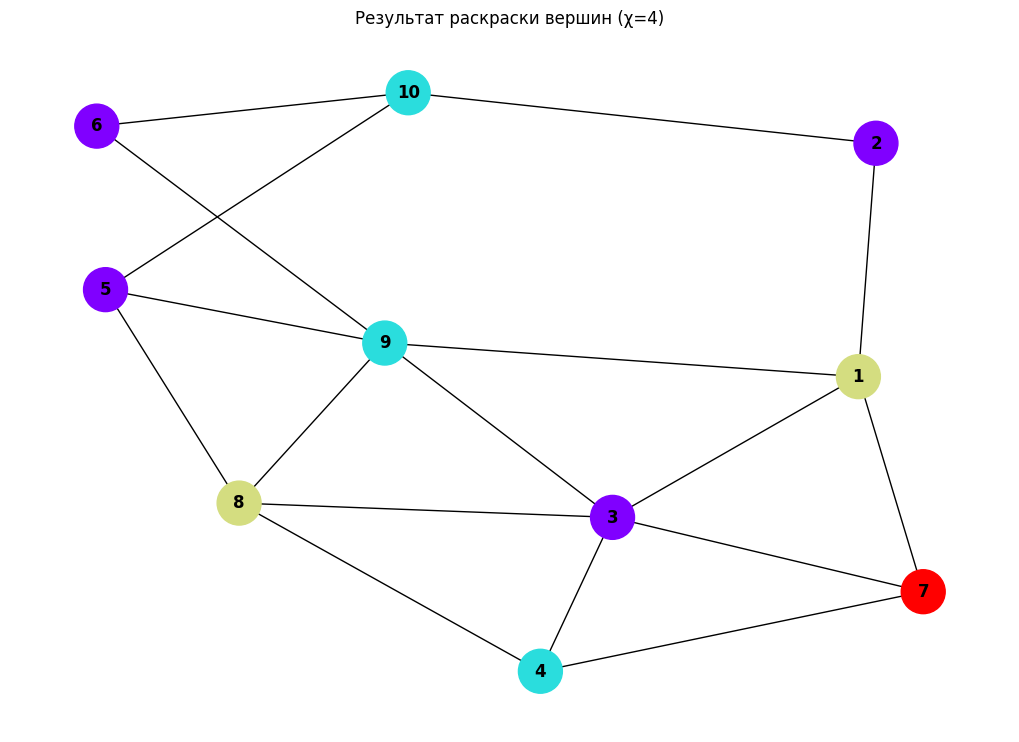

In [14]:
# 1. Создание графа из матрицы
matrix = [
    [0, 1, 1, 0, 0, 0, 1, 0, 1, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 1, 0, 0, 1, 1, 1, 0], [0, 0, 1, 0, 0, 0, 1, 1, 0, 0],
    [1, 0, 0, 0, 0, 0, 0, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 0, 0, 0, 1, 0],
    [1, 0, 1, 0, 1, 1, 0, 1, 0, 0], [0, 1, 0, 0, 1, 1, 0, 0, 0, 0]
]

G = nx.Graph()
for i in range(10):
    for j in range(i + 1, 10):
        if matrix[i][j] == 1: G.add_edge(i + 1, j + 1)

# 2. Порядок Largest First (сначала степень, потом номер вершины)
nodes_ordered = sorted(G.degree, key=lambda x: (x[1], -x[0]), reverse=True)
ordered_list = [node for node, deg in nodes_ordered]

# 3. Пошаговая жадная раскраска
coloring = {}
for node in ordered_list:
    # Смотрим цвета соседей, которые уже покрашены
    neighbor_colors = {coloring[neighbor] for neighbor in G.neighbors(node) if neighbor in coloring}
    color = 0
    while color in neighbor_colors: 
        color += 1
    coloring[node] = color

# 4. Вычисления для оценок
max_deg = max(dict(G.degree).values())
num_colors = max(coloring.values()) + 1
# Находим размер максимальной клики для нижней оценки
from networkx.algorithms.approximation import clique
max_clique_nodes = clique.max_clique(G)
clique_num = len(max_clique_nodes)

print(f"Порядок раскраски: {ordered_list}")
print(f"Распределение цветов: {coloring}")
print(f"Использовано цветов (χ): {num_colors}")
print(f"Нижняя оценка (ω): {clique_num}")
print(f"Верхняя оценка (Δ+1): {max_deg + 1}")

# 5. Визуализация
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
node_colors_list = [coloring[n] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors_list, 
        cmap=plt.cm.rainbow, node_size=1000, font_weight='bold')
plt.title(f"Результат раскраски вершин (χ={num_colors})")
plt.show()